In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [12]:
import kagglehub
path = kagglehub.dataset_download("chandanakuntala/cropped-lisa-traffic-light-dataset")

Using Colab cache for faster access to the 'cropped-lisa-traffic-light-dataset' dataset.


In [13]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/cropped-lisa-traffic-light-dataset
['cropped_lisa_1']


In [14]:
path = kagglehub.dataset_download("chandanakuntala/cropped-lisa-traffic-light-dataset")

print("Dataset downloaded to:", path)

for root, dirs, files in os.walk(path):
    print(root)

Using Colab cache for faster access to the 'cropped-lisa-traffic-light-dataset' dataset.
Dataset downloaded to: /kaggle/input/cropped-lisa-traffic-light-dataset
/kaggle/input/cropped-lisa-traffic-light-dataset
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1/goForward
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1/warning
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1/stopLeft
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1/warningLeft
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1/go
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1/goLeft
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1/stop
/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/val_1
/kaggle/input/cropped-lisa

In [15]:
#dataset_path = "/kagglehub/datasets/chandanakuntala/cropped-lisa-traffic-light-dataset/versions/1"

train_path = "/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/train_1"
valid_path = "/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/val_1"

In [16]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42 #seed used to initialize a random number generator.

In [17]:
#creating the train_ds and valid_ds dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,#32 images together into one batch.
    shuffle=True,#The images are randomly shuffled before creating batches.
    seed=SEED
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 32797 files belonging to 7 classes.
Found 3737 files belonging to 7 classes.


In [18]:
class_names = train_ds.class_names

print(class_names)

['go', 'goForward', 'goLeft', 'stop', 'stopLeft', 'warning', 'warningLeft']


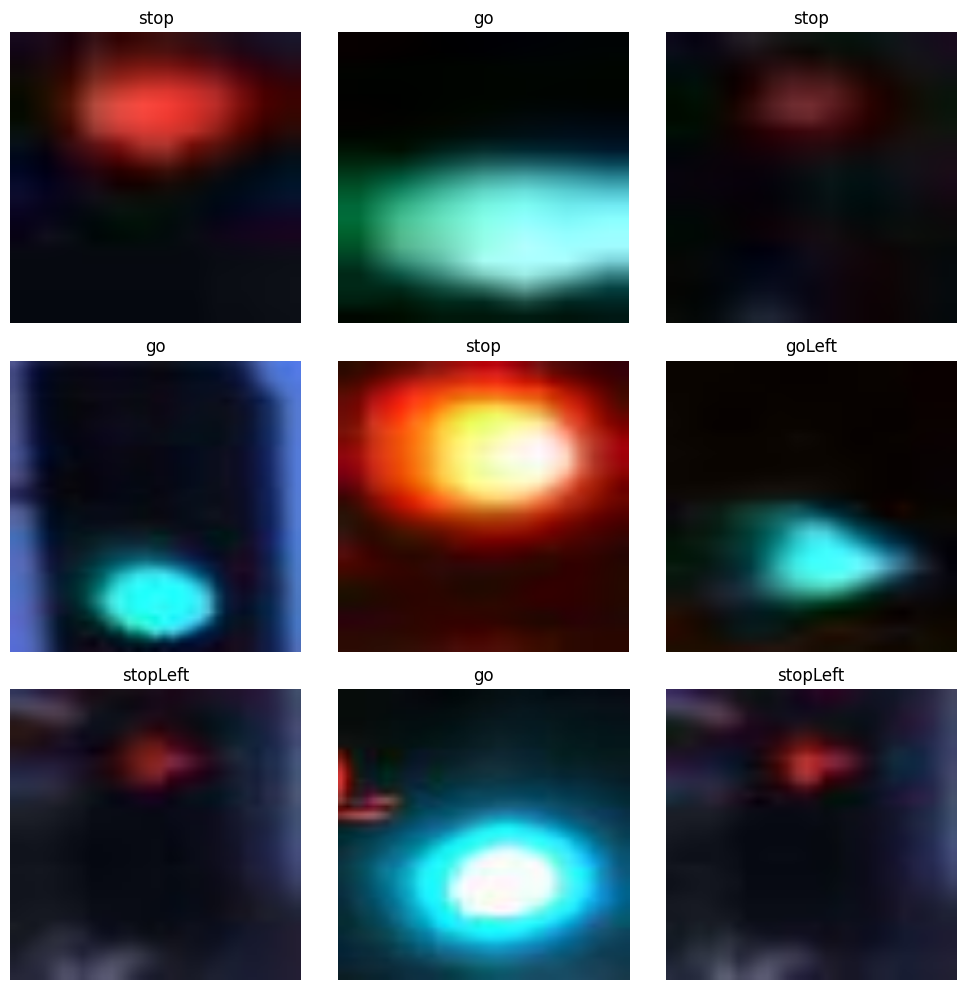

In [19]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
#counting images in each class
class_counts = {}

for images, labels in train_ds:

    for label in labels.numpy():

        class_name = class_names[label]

        class_counts[class_name] = class_counts.get(class_name, 0) + 1

print(class_counts)

{'goLeft': 1030, 'stop': 14865, 'stopLeft': 2845, 'goForward': 184, 'go': 12840, 'warning': 985, 'warningLeft': 48}


In [21]:
#optimization that makes the data pipeline more efficient so your GPU spends less time waiting for data.

#prefetch() makes your training faster by preparing the next batch of data while the GPU is training on the current batch.
AUTOTUNE = tf.data.AUTOTUNE #Automatically determine the best number of batches to prepare in advance based on the available CPU and GPU resources."

train_ds = train_ds.prefetch(AUTOTUNE)

valid_ds = valid_ds.prefetch(AUTOTUNE)

In [22]:
#During training, TensorFlow randomly transforms each image before sending it to the model. like flip,rotate or zoom so that it can get more details from the images
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])

In [23]:
# Here we are using Transfer lerning concept
# using EfficientNetB0 as the pretrained base model. EfficientNetB0 is a Convolutional Neural Network (CNN) developed by Google.
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3) #giving the input shape of images
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
base_model.trainable = False # directing not to change the weights of EfficientNetB0 during training."

In [25]:
print(base_model.trainable)

False


In [26]:
#building cnn architecture
#using x to provide the output of one layer to next layer
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)#Converts the image into the format expected by EfficientNetB0.
x = base_model(x, training=False)#this line extracts features
x = tf.keras.layers.GlobalAveragePooling2D()(x)#This layer basically converts the feature map  into a compact vector:
x = tf.keras.layers.Dropout(0.3)(x)#for randomness
outputs = tf.keras.layers.Dense(7,activation="softmax")(x)# we have 7 outputs so using softmax
model = tf.keras.Model(inputs, outputs)

In [27]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [28]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),#The learning rate determines how fast or how slowly the model learns from its mistakes.
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [29]:
#it stops the model early when it stops improving it prevent training time and overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",# it monitoes validation loss for improvement
    patience=5,#waits 5 consecutive epochs before stoping
    restore_best_weights=True
)

In [30]:
#automatically save the best-performing model during training.
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "traffic_light_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [31]:
#automatically reduces the learning rate when the model stops improving,
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2, #when no improvements it multiplies learning rate by 0.2
    patience=3,
    min_lr=1e-6
)

In [32]:
#model training
history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=20,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 106s 90ms/step - accuracy: 0.7506 - loss: 0.7869 - val_accuracy: 0.8368 - val_loss: 0.6221 - learning_rate: 1.0000e-04
Epoch 2/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 89s 87ms/step - accuracy: 0.8561 - loss: 0.4552 - val_accuracy: 0.8558 - val_loss: 0.5162 - learning_rate: 1.0000e-04
Epoch 3/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 93s 90ms/step - accuracy: 0.8815 - loss: 0.3694 - val_accuracy: 0.8780 - val_loss: 0.4506 - learning_rate: 1.0000e-04
Epoch 4/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 93s 91ms/step - accuracy: 0.8946 - loss: 0.3234 - val_accuracy: 0.8868 - val_loss: 0.4065 - learning_rate: 1.0000e-04
Epoch 5/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 139s 88ms/step - accuracy: 0.9065 - loss: 0.2907 - val_accuracy: 0.8943 - val_loss: 0.3777 - learning_rate: 1.0000e-04
Epoch 6/20
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 90s 88ms/step - accuracy: 0.9153 - loss: 0.2655 - val_accuracy: 0.9002 - val_loss: 0.3568 - learning_rate: 1.0000e-04
Epoch 7/20
1025/1025 ━━━━━━━━━━━━━━━━━

In [33]:
print(class_names)

['go', 'goForward', 'goLeft', 'stop', 'stopLeft', 'warning', 'warningLeft']


In [34]:
loss, accuracy = model.evaluate(valid_ds)

print(f"Accuracy: {accuracy:.4f}")

117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.9136 - loss: 0.2711
Accuracy: 0.9136


In [35]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in valid_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

          go       0.96      1.00      0.98      1372
   goForward       1.00      0.86      0.92        21
      goLeft       0.93      0.59      0.72       109
        stop       0.88      0.99      0.93      1777
    stopLeft       0.93      0.29      0.44       345
     warning       0.98      0.94      0.96       108
 warningLeft       1.00      0.80      0.89         5

    accuracy                           0.91      3737
   macro avg       0.95      0.78      0.83      3737
weighted avg       0.92      0.91      0.90      3737



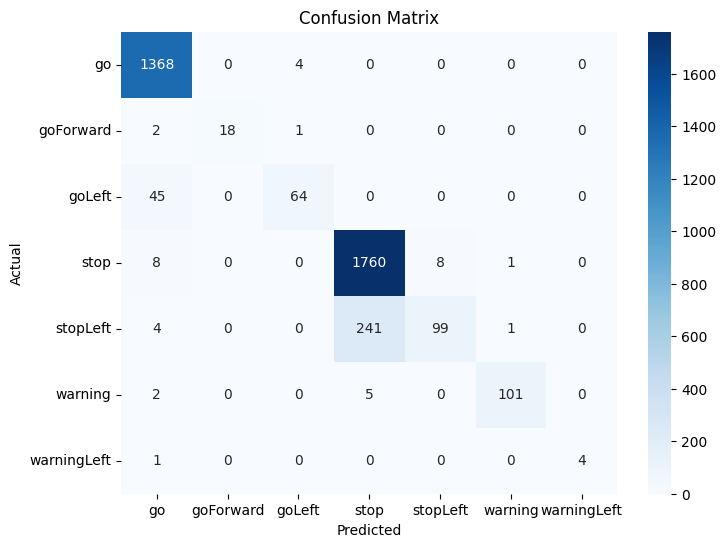

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
#very less wrong prediction except stop left and stop

In [37]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

Precision: 0.9161914387029189


In [40]:
import os
import glob
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image

# Load model
model = tf.keras.models.load_model("/content/traffic_light_model.keras")#loading the trained model

# Class names
class_names = [
    "go",
    "goForward",
    "goLeft",
    "stop",
    "stopLeft",
    "warning",
    "warningLeft"
]

# Prediction Function
def predict_traffic_light(img):

    img = img.resize((224, 224))
    img = np.array(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)[0]

    return {
        class_names[i]: float(prediction[i])
        for i in range(len(class_names))
    }

# example samples from each class
dataset_path = "/kaggle/input/cropped-lisa-traffic-light-dataset/cropped_lisa_1/val_1"

examples = []
for cls in class_names:
    images = glob.glob(os.path.join(dataset_path, cls, "*.jpg"))
    if len(images) > 0:
        examples.append([images[0]])



demo = gr.Interface(
    fn=predict_traffic_light,
    inputs=gr.Image(type="pil", label="Upload Traffic Light"),
    outputs=gr.Label(num_top_classes=7, label="Prediction"),
    examples=examples,
    title="🚦 Traffic Light Recognition",
    description="Upload an image or click one of the example images below."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://473351226453f6d74f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
